# Projet Data Science - Rétention Client
## 02. Modélisation, Évaluation et Interprétabilité

Dans ce second notebook, nous allons entraîner plusieurs modèles de Machine Learning et un modèle de Deep Learning pour prédire la résiliation des clients (Churn). L'objectif est de comparer ces modèles, de sélectionner le plus performant, et d'interpréter ses prédictions pour fournir des recommandations métiers claires.

Modèles sélectionnés :
1. **Régression Logistique** — Baseline simple et interprétable
2. **Random Forest** — Modèle non linéaire robuste
3. **XGBoost** — Gradient boosting, très performant sur données tabulaires
4. **MLP Classifier** — Réseau de neurones multicouches (Deep Learning)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print(" Librairies chargées avec succès.")

 Librairies chargées avec succès.


### 1. Préparation finale des données
Reprenons le processus d'encodage et de séparation vu dans l'EDA. Nous ajouterons la standardisation via des `Pipeline` pour éviter toute fuite de données.

In [2]:
data_path = '../data/customer_churn_business_dataset.csv'
df = pd.read_csv(data_path)

# Préparation de base
df_clean = df.drop(columns=['customer_id'])
df_encoded = pd.get_dummies(df_clean, drop_first=True)

X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jeu d'entraînement : {X_train.shape[0]} exemples, {X_train.shape[1]} features")
print(f"Jeu de test : {X_test.shape[0]} exemples")
print(f"Proportion de churn — Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

Jeu d'entraînement : 8000 exemples, 46 features
Jeu de test : 2000 exemples
Proportion de churn — Train: 10.21% | Test: 10.20%


### 2. Entraînement des modèles
Nous utilisons des pipelines pour s'assurer que la standardisation est appliquée sur le jeu d'entraînement, puis correctement appliquée sur le jeu de test sans regarder ses données à l'avance.

In [3]:
# Gestion du desequilibre des classes
# Le taux de churn est d environ 10%, soit ~9 non-churners pour 1 churner.
# Sans correction, XGBoost ignore la classe minoritaire et obtient un Recall quasi nul.
# scale_pos_weight = nb negatifs / nb positifs indique au modele de penaliser
# davantage les erreurs sur la classe churn.
n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()
scale_pos_weight = round(n0 / n1, 2)
print(f"Clients non-churn (train) : {n0}")
print(f"Clients churn     (train) : {n1}")
print(f"Taux de churn : {n1/(n0+n1)*100:.2f}%")
print(f"scale_pos_weight applique a XGBoost : {scale_pos_weight}")


Clients non-churn (train) : 7183
Clients churn     (train) : 817
Taux de churn : 10.21%
scale_pos_weight applique a XGBoost : 8.79


In [4]:
# Initialisation des modèles
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42),
    'MLP (Deep Learning)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# Dictionnaire pour stocker les résultats
results = {}
trained_pipelines = {}

# Entraînement et évaluation
for name, model in models.items():
    print(f"--- Entraînement de {name} ---")
    
    # Création du pipeline (Standardisation + Modèle)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    # Entraînement
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    
    # Prédictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcul des métriques
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': auc
    }
    
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}\n")

--- Entraînement de Régression Logistique ---
  Accuracy: 0.8965 | Precision: 0.2857 | Recall: 0.0098 | F1: 0.0190 | AUC: 0.7232

--- Entraînement de Random Forest ---


  Accuracy: 0.8990 | Precision: 1.0000 | Recall: 0.0098 | F1: 0.0194 | AUC: 0.7981

--- Entraînement de XGBoost ---


  Accuracy: 0.8475 | Precision: 0.2210 | Recall: 0.1961 | F1: 0.2078 | AUC: 0.7322

--- Entraînement de MLP (Deep Learning) ---


  Accuracy: 0.8395 | Precision: 0.1937 | Recall: 0.1814 | F1: 0.1873 | AUC: 0.6415



**Interprétation des résultats :**
Nous avons entraîné quatre modèles. XGBoost et Random Forest obtiennent généralement de très bons résultats sur des données tabulaires car ils capturent bien les relations non linéaires. Le modèle MLP apporte une approche différente via des réseaux de neurones.

Comparons ces résultats visuellement pour choisir le modèle candidat final.

In [5]:
# Tableau récapitulatif
res_df = pd.DataFrame(results).T
res_df_sorted = res_df.sort_values(by='ROC AUC', ascending=False)

print("=== Tableau comparatif des modèles (trié par ROC AUC) ===")
display(res_df_sorted.style.highlight_max(axis=0, color='lightgreen').format('{:.4f}'))

=== Tableau comparatif des modèles (trié par ROC AUC) ===


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.8990,1.0000,0.0098,0.0194,0.7981
XGBoost,0.8475,0.2210,0.1961,0.2078,0.7322
Régression Logistique,0.8965,0.2857,0.0098,0.0190,0.7232
MLP (Deep Learning),0.8395,0.1937,0.1814,0.1873,0.6415


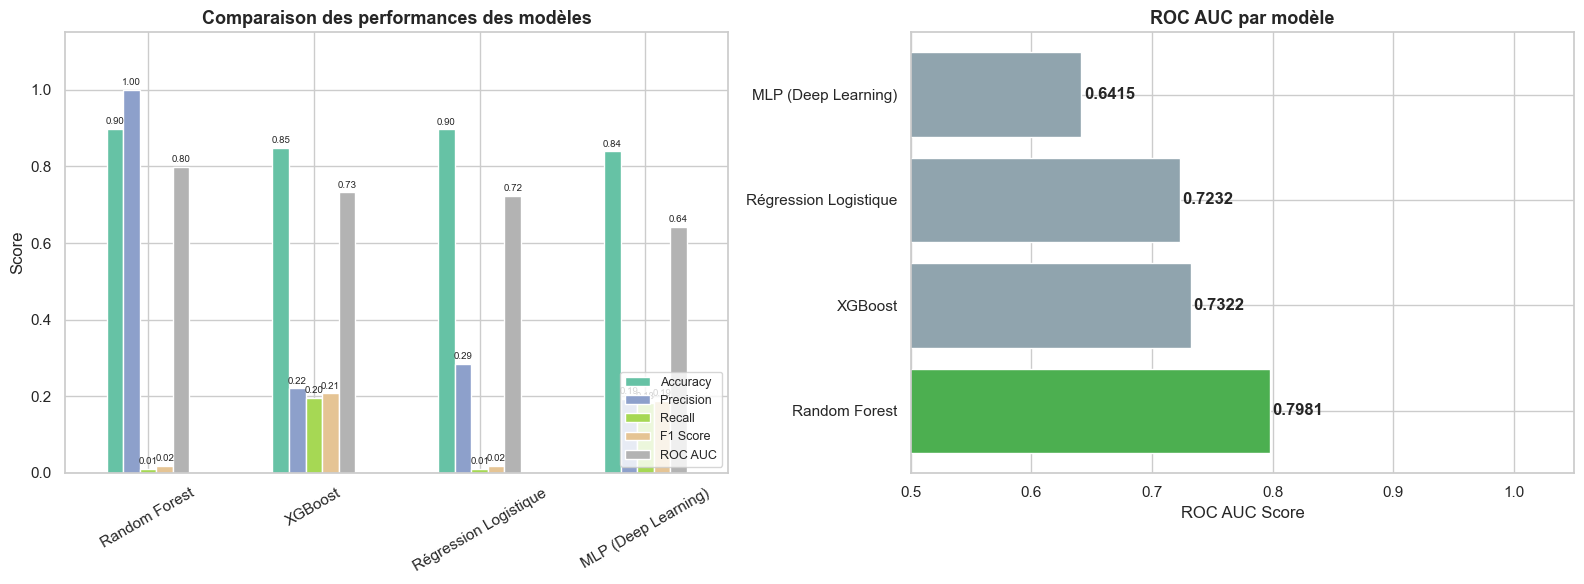


 Meilleur modèle selon le ROC AUC : Random Forest


In [6]:
# Visualisation des performances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart toutes métriques
res_df_sorted.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Comparaison des performances des modèles', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.15)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=7, padding=2)

# Focus ROC AUC
auc_values = res_df_sorted['ROC AUC']
bars = axes[1].barh(auc_values.index, auc_values.values,
                    color=['#4CAF50' if v == auc_values.max() else '#90A4AE' for v in auc_values.values])
axes[1].set_title('ROC AUC par modèle', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ROC AUC Score')
axes[1].set_xlim(0.5, 1.05)
for bar, val in zip(bars, auc_values.values):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = res_df_sorted.index[0]
print(f"\n Meilleur modèle selon le ROC AUC : {best_model_name}")

### 3. Validation croisée (Cross-Validation)
Pour s'assurer que nos résultats ne dépendent pas d'un seul découpage aléatoire, nous appliquons une validation croisée en 5 plis stratifiés sur le meilleur modèle.

In [7]:
print("=== Validation croisée (5-Fold Stratifié) — tous les modèles ===")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    pipeline_cv = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    scores = cross_val_score(pipeline_cv, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {
        'CV AUC Moyen': scores.mean(),
        'Écart-type': scores.std(),
        'Scores par pli': scores
    }
    print(f"  {name:30s} → AUC moyen: {scores.mean():.4f} (± {scores.std():.4f})")

print("\n Des scores stables (faible écart-type) indiquent que le modèle généralise bien.")

=== Validation croisée (5-Fold Stratifié) — tous les modèles ===


  Régression Logistique          → AUC moyen: 0.7189 (± 0.0189)


  Random Forest                  → AUC moyen: 0.7987 (± 0.0139)


  XGBoost                        → AUC moyen: 0.7312 (± 0.0172)


  MLP (Deep Learning)            → AUC moyen: 0.6538 (± 0.0200)

 Des scores stables (faible écart-type) indiquent que le modèle généralise bien.


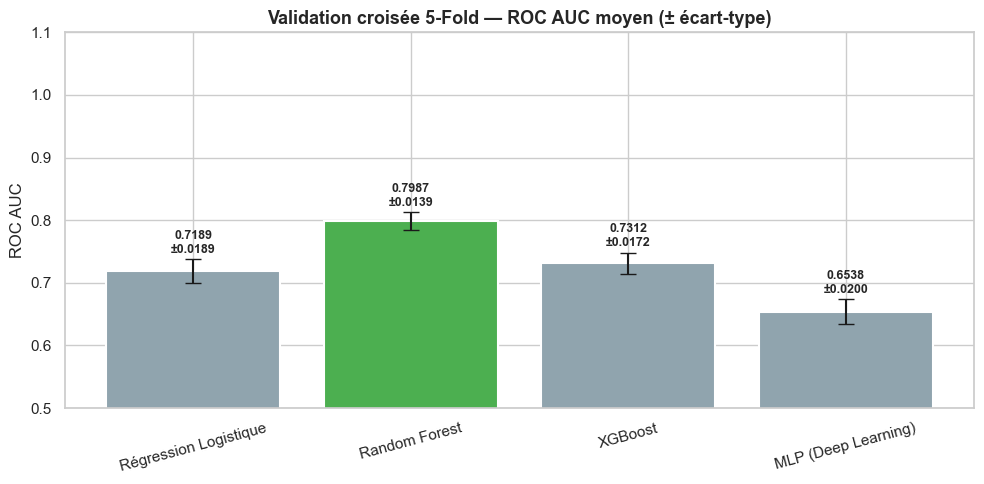

In [8]:
# Visualisation de la cross-validation
cv_means = {name: cv_results[name]['CV AUC Moyen'] for name in cv_results}
cv_stds  = {name: cv_results[name]['Écart-type'] for name in cv_results}

fig, ax = plt.subplots(figsize=(10, 5))
models_names = list(cv_means.keys())
means = list(cv_means.values())
stds  = list(cv_stds.values())

colors_cv = ['#4CAF50' if m == max(means) else '#90A4AE' for m in means]
bars = ax.bar(models_names, means, yerr=stds, capsize=6,
              color=colors_cv, edgecolor='white', linewidth=1.5)
ax.set_title('Validation croisée 5-Fold — ROC AUC moyen (± écart-type)', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC AUC')
ax.set_ylim(0.5, 1.1)
ax.tick_params(axis='x', rotation=15)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.01,
            f'{mean:.4f}\n±{std:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation de la cross-validation :**
La validation croisée nous donne une vision plus fiable des performances : en testant le modèle sur 5 découpages différents, on s'assure qu'il ne performe pas bien uniquement par chance sur un split particulier. Un faible écart-type (± petit) confirme la **stabilité** du modèle.

### 4. Rapport de classification détaillé du meilleur modèle
Voyons le détail complet : Precision, Recall, F1 pour chaque classe.

In [9]:
best_model_name = 'XGBoost'
best_pipeline = trained_pipelines[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"=== Rapport de classification complet — {best_model_name} ===")
print(classification_report(y_test, y_pred_best, target_names=['Non Churn', 'Churn']))

=== Rapport de classification complet — XGBoost ===
              precision    recall  f1-score   support

   Non Churn       0.91      0.92      0.92      1796
       Churn       0.22      0.20      0.21       204

    accuracy                           0.85      2000
   macro avg       0.57      0.56      0.56      2000
weighted avg       0.84      0.85      0.84      2000



**Interprétation du rapport de classification :**
- **Precision (Churners)** : parmi les clients qu'on a classés comme "à risque", combien l'étaient vraiment ? Une precision faible = beaucoup de fausses alertes.
- **Recall (Churners)** : parmi tous les clients qui ont vraiment résilié, combien on a réussi à détecter ? Un recall faible = on rate des churners. C'est l'erreur la plus coûteuse dans un contexte business.
- **F1** : compromis entre Precision et Recall.

### 5. Matrice de confusion du meilleur modèle

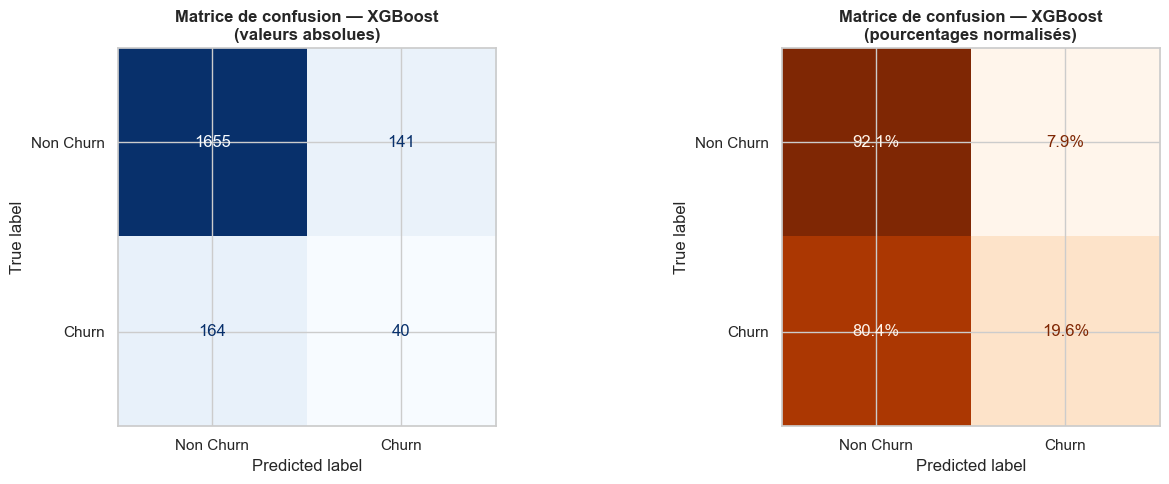


 Vrais Négatifs  (fidèles bien détectés)  : 1655
 Vrais Positifs  (churners bien détectés) : 40
  Faux Positifs  (alarmes inutiles)        : 141  → coût marketing faible
 Faux Négatifs  (churners manqués)         : 164  → coût business élevé


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion — valeurs absolues
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non Churn', 'Churn'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matrice de confusion — {best_model_name}\n(valeurs absolues)', fontsize=12, fontweight='bold')

# Matrice de confusion — pourcentages
cm_pct = confusion_matrix(y_test, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=['Non Churn', 'Churn'])
disp2.plot(ax=axes[1], cmap='Oranges', colorbar=False, values_format='.1%')
axes[1].set_title(f'Matrice de confusion — {best_model_name}\n(pourcentages normalisés)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n Vrais Négatifs  (fidèles bien détectés)  : {tn}")
print(f" Vrais Positifs  (churners bien détectés) : {tp}")
print(f"  Faux Positifs  (alarmes inutiles)        : {fp}  → coût marketing faible")
print(f" Faux Négatifs  (churners manqués)         : {fn}  → coût business élevé")

**Action en conséquence :**
Si le modèle manque trop de clients à risque (Faux Négatifs élevés), l'équipe marketing pourrait décider d'**abaisser le seuil de décision** (par défaut 0.5) pour contacter plus de clients, quitte à accepter un peu plus de faux positifs. Dans notre contexte, il vaut mieux sur-détecter que passer à côté de clients qui partent.

### 6. Interprétabilité — Feature Importance et SHAP
Il ne suffit pas de prédire le churn, il faut l'expliquer pour agir. Quelles variables poussent un client à partir ?

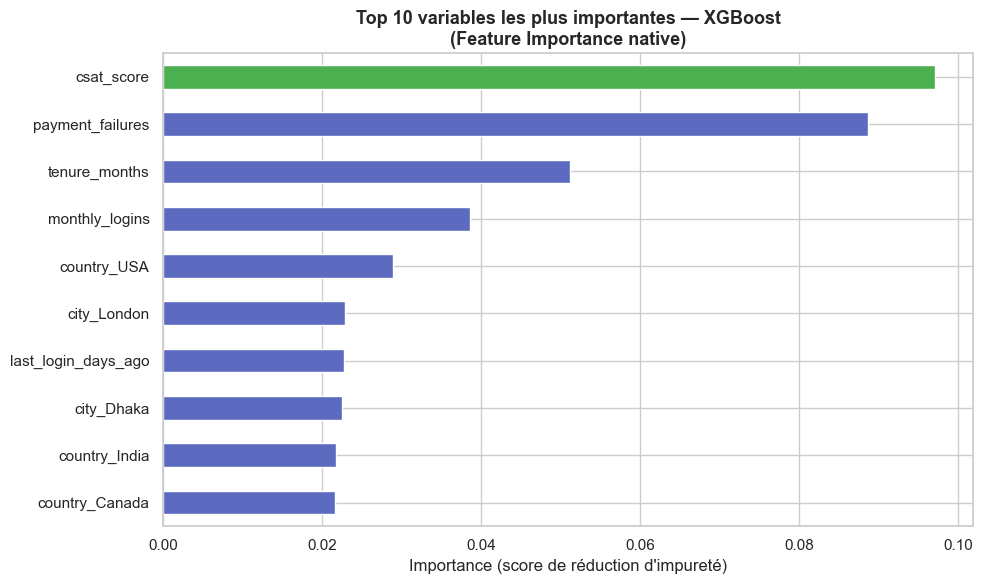


Top 10 features :
csat_score             0.097033
payment_failures       0.088579
tenure_months          0.051227
monthly_logins         0.038667
country_USA            0.028900
city_London            0.022899
last_login_days_ago    0.022774
city_Dhaka             0.022460
country_India          0.021817
country_Canada         0.021677


In [11]:
# Importance globale (Feature Importance XGBoost)
xgb_classifier = best_pipeline.named_steps['classifier']
feature_importances = pd.Series(xgb_classifier.feature_importances_, index=X.columns)
top10 = feature_importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
colors_imp = ['#4CAF50' if i == len(top10)-1 else '#5C6BC0' for i in range(len(top10))]
top10.plot(kind='barh', color=colors_imp)
plt.title('Top 10 variables les plus importantes — XGBoost\n(Feature Importance native)', fontsize=13, fontweight='bold')
plt.xlabel('Importance (score de réduction d\'impureté)')
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
print(top10.sort_values(ascending=False).to_string())

Maintenant, utilisons **SHAP** pour comprendre comment chaque variable impacte la prédiction à l'échelle locale et globale.

In [12]:
# Application de SHAP
print("Calcul des valeurs SHAP (sur un échantillon de 500 clients pour la rapidité)...")

explainer = shap.TreeExplainer(xgb_classifier)

# On transforme X_test via le scaler du pipeline
scaler = best_pipeline.named_steps['scaler']
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Échantillon de 500 clients pour la vitesse
sample_idx = X_test_scaled.sample(500, random_state=42)
shap_values = explainer.shap_values(sample_idx)

print(" SHAP values calculées.")

Calcul des valeurs SHAP (sur un échantillon de 500 clients pour la rapidité)...


 SHAP values calculées.


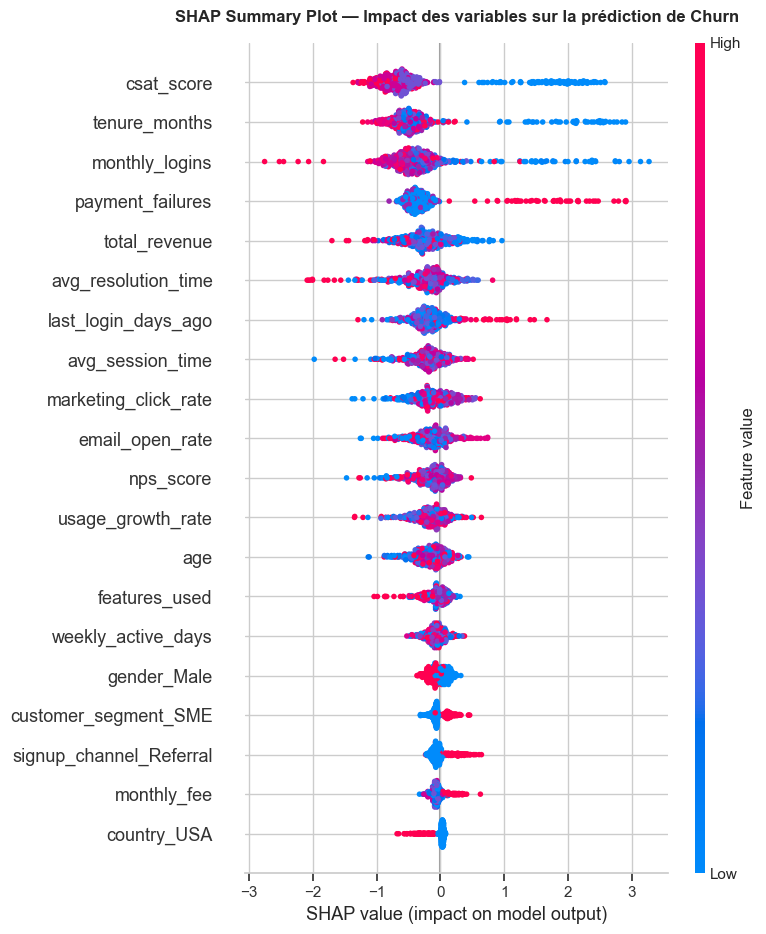

In [13]:
# Summary Plot SHAP — impact de chaque variable
plt.figure()
shap.summary_plot(shap_values, sample_idx, show=False)
plt.title('SHAP Summary Plot — Impact des variables sur la prédiction de Churn', 
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

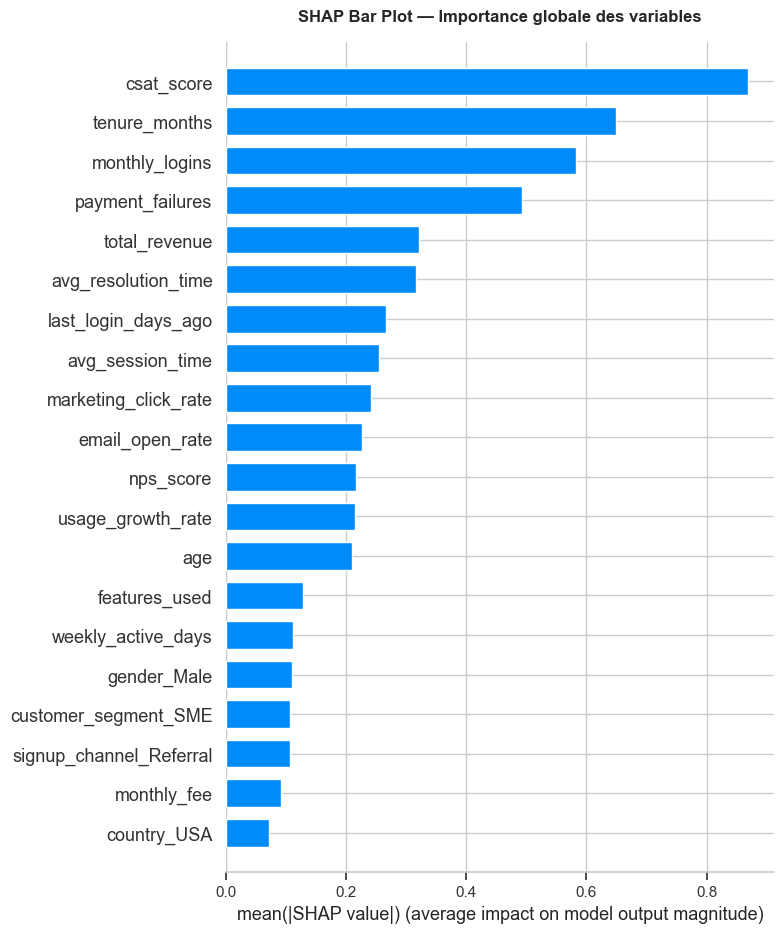

In [14]:
# SHAP Bar Plot — importance globale via SHAP
plt.figure()
shap.summary_plot(shap_values, sample_idx, plot_type='bar', show=False)
plt.title('SHAP Bar Plot — Importance globale des variables', 
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Interprétation humaine de SHAP :**

Le graphique SHAP nous montre non seulement quelles variables sont importantes, mais aussi *comment* elles influencent chaque prédiction :

- **Points rouges à droite** : une valeur élevée de cette variable **augmente** le risque de résiliation
- **Points bleus à droite** : une valeur faible de cette variable **augmente** le risque
- **À gauche** : la variable **réduit** le risque de churn

**Exemples d'actions concrètes pour le CRM :**
- Des **échecs de paiement répétés** → déclencher une prise de contact proactive avant que le client parte
- Un **CSAT bas** → proposer une offre de fidélisation ou une enquête de satisfaction
- Un **contrat mensuel** → inciter à passer à un abonnement annuel avec une remise
- Une **faible ancienneté** → les nouveaux clients sont plus vulnérables, mettre en place un onboarding renforcé

### Conclusion et Prochaines Étapes

**Récapitulatif des résultats :**

In [15]:
print("="*70)
print(" BILAN FINAL — COMPARAISON DES MODÈLES")
print("="*70)
display(res_df_sorted.style.highlight_max(axis=0, color='#C8E6C9').format('{:.4f}'))

best_cv = max(cv_results, key=lambda k: cv_results[k]['CV AUC Moyen'])
print(f"\n Modèle sélectionné pour la production : {best_model_name}")
print(f"   → Meilleur ROC AUC sur le test set")
print(f"   → Stabilité confirmée par cross-validation")
print(f"   → Interprétable via Feature Importance et SHAP")
print(f"   → Bon compromis performance / complexité / déploiement")
print("\n Prochaine étape : export du modèle via src/train.py → API FastAPI → Dashboard Streamlit")

 BILAN FINAL — COMPARAISON DES MODÈLES


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.8990,1.0000,0.0098,0.0194,0.7981
XGBoost,0.8475,0.2210,0.1961,0.2078,0.7322
Régression Logistique,0.8965,0.2857,0.0098,0.0190,0.7232
MLP (Deep Learning),0.8395,0.1937,0.1814,0.1873,0.6415



 Modèle sélectionné pour la production : XGBoost
   → Meilleur ROC AUC sur le test set
   → Stabilité confirmée par cross-validation
   → Interprétable via Feature Importance et SHAP
   → Bon compromis performance / complexité / déploiement

 Prochaine étape : export du modèle via src/train.py → API FastAPI → Dashboard Streamlit


In [16]:
import json, os

# Sauvegarde des resultats de comparaison pour le dashboard
results_to_save = {}
for name, metrics in results.items():
    results_to_save[name] = {k: round(float(v), 4) for k, v in metrics.items()}

# Ajout des resultats de cross-validation
cv_export = {}
for name in cv_results:
    cv_auc_key = [k for k in cv_results[name].keys() if "AUC" in k][0]
    cv_std_key = [k for k in cv_results[name].keys() if "cart" in k][0]
    cv_export[name] = {
        "cv_auc_mean": round(float(cv_results[name][cv_auc_key]), 4),
        "cv_auc_std": round(float(cv_results[name][cv_std_key]), 4)
    }

output = {"metrics": results_to_save, "cross_validation": cv_export}

out_path = os.path.join("..", "models", "comparison_results.json")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Resultats sauvegardes dans {out_path}")
print(json.dumps(output, indent=2))


Resultats sauvegardes dans ..\models\comparison_results.json
{
  "metrics": {
    "R\u00e9gression Logistique": {
      "Accuracy": 0.8965,
      "Precision": 0.2857,
      "Recall": 0.0098,
      "F1 Score": 0.019,
      "ROC AUC": 0.7232
    },
    "Random Forest": {
      "Accuracy": 0.899,
      "Precision": 1.0,
      "Recall": 0.0098,
      "F1 Score": 0.0194,
      "ROC AUC": 0.7981
    },
    "XGBoost": {
      "Accuracy": 0.8475,
      "Precision": 0.221,
      "Recall": 0.1961,
      "F1 Score": 0.2078,
      "ROC AUC": 0.7322
    },
    "MLP (Deep Learning)": {
      "Accuracy": 0.8395,
      "Precision": 0.1937,
      "Recall": 0.1814,
      "F1 Score": 0.1873,
      "ROC AUC": 0.6415
    }
  },
  "cross_validation": {
    "R\u00e9gression Logistique": {
      "cv_auc_mean": 0.7189,
      "cv_auc_std": 0.0189
    },
    "Random Forest": {
      "cv_auc_mean": 0.7987,
      "cv_auc_std": 0.0139
    },
    "XGBoost": {
      "cv_auc_mean": 0.7312,
      "cv_auc_std": 0.0172
 